# Hodgkin–Huxley: dynamics of the single-patch ODEs

This notebook explores the 4 coupled ODEs of a space-clamped (0D) patch of membrane, modern convention (V in mV, rest ≈ −65 mV):

$$C_m \frac{dV}{dt} = I_{ext} - \bar g_{Na} m^3 h (V-E_{Na}) - \bar g_K n^4 (V-E_K) - \bar g_L (V-E_L)$$
$$\frac{dx}{dt} = \alpha_x(V)(1-x) - \beta_x(V)\,x = \frac{x_\infty(V)-x}{\tau_x(V)}, \quad x\in\{n,m,h\}$$

**Sections**
1. Model definition
2. Gate steady states $x_\infty(V)$ and time constants $\tau_x(V)$
3. Resting state check
4. Gates under voltage clamp
5. A single action potential (voltage, gates, currents)
6. Threshold: sub- vs supra-threshold stimuli
7. Refractory period
8. Repetitive firing and the f–I curve
9. Phase-space view (V–n plane)
10. Forward Euler vs Rush–Larsen

## 1. Model definition

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

# Parameters (squid giant axon, modern convention)
Cm = 1.0                                  # uF/cm^2
gNa, gK, gL = 120.0, 36.0, 0.3            # mS/cm^2
ENa, EK, EL = 50.0, -77.0, -54.4          # mV
V0 = -65.0                                # resting potential, mV

def vtrap(x, y):
    # x / (1 - exp(-x/y)), safe at x = 0 (limit = y)
    x = np.asarray(x, dtype=float)
    small = np.abs(x / y) < 1e-6
    safe = np.where(small, 1.0, x)
    return np.where(small, y * (1 + x / (2 * y)), safe / (1 - np.exp(-safe / y)))

# Rate functions (1/ms)
def alpha_n(V): return 0.01 * vtrap(V + 55, 10)
def beta_n(V):  return 0.125 * np.exp(-(V + 65) / 80)
def alpha_m(V): return 0.1 * vtrap(V + 40, 10)
def beta_m(V):  return 4.0 * np.exp(-(V + 65) / 18)
def alpha_h(V): return 0.07 * np.exp(-(V + 65) / 20)
def beta_h(V):  return 1.0 / (1 + np.exp(-(V + 35) / 10))

RATES = {"n": (alpha_n, beta_n), "m": (alpha_m, beta_m), "h": (alpha_h, beta_h)}

def x_inf(gate, V):
    a, b = RATES[gate]
    return a(V) / (a(V) + b(V))

def tau(gate, V):
    a, b = RATES[gate]
    return 1.0 / (a(V) + b(V))

def currents(V, m, h, n):
    INa = gNa * m**3 * h * (V - ENa)
    IK  = gK * n**4 * (V - EK)
    IL  = gL * (V - EL)
    return INa, IK, IL

def hh_rhs(t, y, Iext):
    # y = [V, m, h, n]; Iext is a function of t
    V, m, h, n = y
    INa, IK, IL = currents(V, m, h, n)
    dV = (Iext(t) - INa - IK - IL) / Cm
    dm = alpha_m(V) * (1 - m) - beta_m(V) * m
    dh = alpha_h(V) * (1 - h) - beta_h(V) * h
    dn = alpha_n(V) * (1 - n) - beta_n(V) * n
    return [dV, dm, dh, dn]

def rest_state(V=V0):
    return [V, float(x_inf("m", V)), float(x_inf("h", V)), float(x_inf("n", V))]

def pulse(amp, t_on, t_off):
    return lambda t: amp if t_on <= t < t_off else 0.0

def simulate(Iext, T=50.0, y0=None, dt_out=0.01):
    y0 = rest_state() if y0 is None else y0
    t_eval = np.arange(0, T, dt_out)
    sol = solve_ivp(hh_rhs, (0, T), y0, args=(Iext,), t_eval=t_eval,
                    method="LSODA", max_step=0.05, rtol=1e-7, atol=1e-9)
    return sol.t, sol.y

COL = {"V": "#222222", "m": "#d1495b", "h": "#edae49", "n": "#00798c",
       "INa": "#d1495b", "IK": "#00798c", "IL": "#888888"}
print("Model ready. Rest state [V, m, h, n] =", np.round(rest_state(), 4))

Model ready. Rest state [V, m, h, n] = [-6.500e+01  5.290e-02  5.961e-01  3.177e-01]


## 2. Gate steady states and time constants

For each gate, $x_\infty = \alpha/(\alpha+\beta)$ is the **target** (fraction open if V were held fixed) and $\tau = 1/(\alpha+\beta)$ is the **speed** of approach.

Things to notice:
- $m_\infty$ and $n_\infty$ rise with depolarization (Boltzmann-like sigmoids); $h_\infty$ falls.
- $\tau_m$ is ~10× smaller than $\tau_h$ and $\tau_n$ → m is the fast gate; h and n are slow.

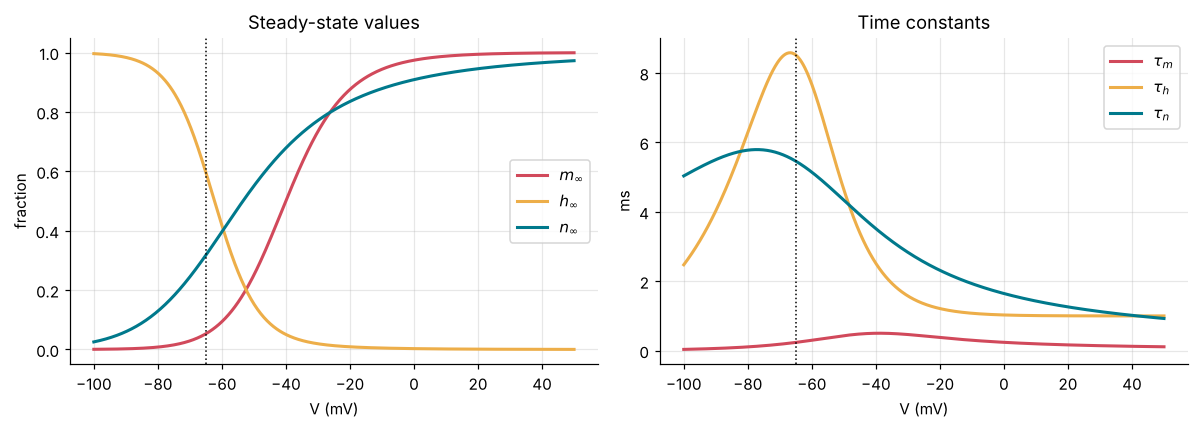

m: x_inf(-65) = 0.053,  tau(-65) = 0.24 ms
h: x_inf(-65) = 0.596,  tau(-65) = 8.52 ms
n: x_inf(-65) = 0.318,  tau(-65) = 5.46 ms


In [2]:
Vr = np.linspace(-100, 50, 600)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for g in "mhn":
    ax[0].plot(Vr, x_inf(g, Vr), color=COL[g], lw=2, label=fr"${g}_\infty$")
    ax[1].plot(Vr, tau(g, Vr), color=COL[g], lw=2, label=fr"$\tau_{g}$")
for a in ax:
    a.axvline(V0, color="k", ls=":", lw=1)
    a.set_xlabel("V (mV)"); a.legend()
ax[0].set_title("Steady-state values"); ax[0].set_ylabel("fraction")
ax[1].set_title("Time constants"); ax[1].set_ylabel("ms")
plt.tight_layout(); plt.show()

for g in "mhn":
    print(f"{g}: x_inf(-65) = {float(x_inf(g, V0)):.3f},  tau(-65) = {float(tau(g, V0)):.2f} ms")

## 3. Resting state check

Start at rest with no stimulus. V should stay flat at −65 mV (this works because $E_L$ = −54.4 mV is tuned so the currents balance at −65 mV).

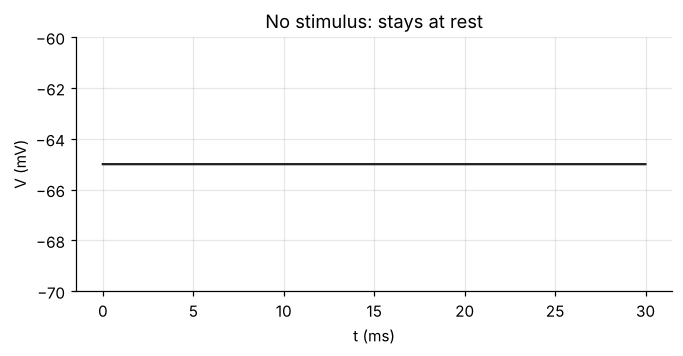

max |V - V0| = 0.0005486430113279539


In [3]:
t, y = simulate(lambda t: 0.0, T=30)
plt.figure(figsize=(7, 3))
plt.plot(t, y[0], color=COL["V"])
plt.ylim(-70, -60); plt.xlabel("t (ms)"); plt.ylabel("V (mV)"); plt.title("No stimulus: stays at rest")
plt.show()
print("max |V - V0| =", np.abs(y[0] - V0).max())

## 4. Gates under voltage clamp

Hold V at rest, then **step** to a fixed command voltage. With V fixed, each gate relaxes exponentially to its new $x_\infty$ with time constant $\tau$ (this is what Hodgkin & Huxley measured).

Watch how $g_{Na} = \bar g_{Na} m^3h$ rises fast and then falls (inactivation), while $g_K = \bar g_K n^4$ rises with a delay (S-shape from the 4th power) and stays up.

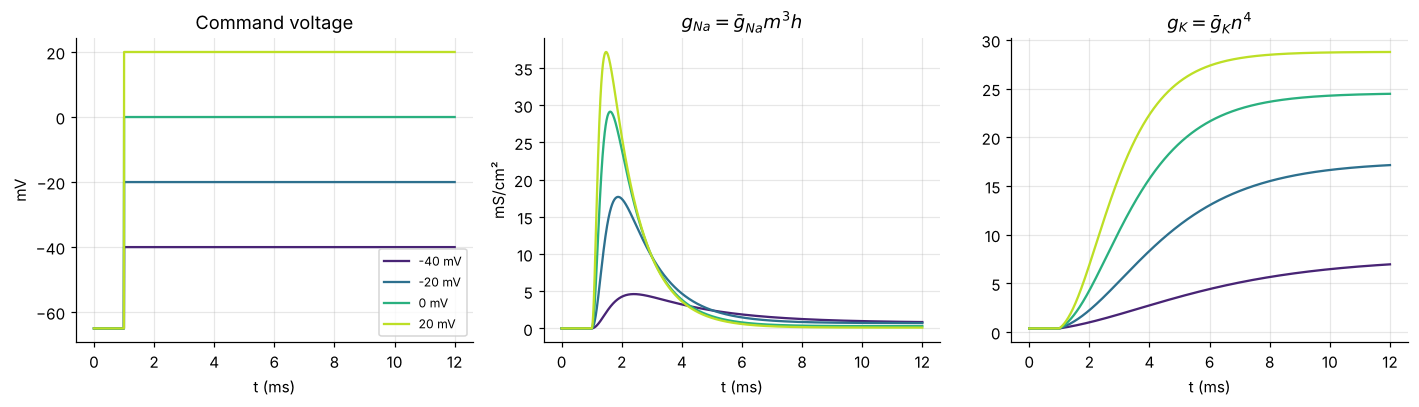

In [4]:
def clamp(Vstep, T=12, t_step=1.0):
    t = np.linspace(0, T, 2000)
    Vt = np.where(t < t_step, V0, Vstep)
    out = {}
    for g in "mhn":
        x0 = x_inf(g, V0); xi = x_inf(g, Vstep); tt = tau(g, Vstep)
        out[g] = np.where(t < t_step, x0, xi + (x0 - xi) * np.exp(-(t - t_step) / tt))
    return t, Vt, out

steps = [-40, -20, 0, 20]
fig, ax = plt.subplots(1, 3, figsize=(13, 3.8))
cmap = plt.cm.viridis(np.linspace(0.1, 0.9, len(steps)))
for Vs, c in zip(steps, cmap):
    t, Vt, g = clamp(Vs)
    ax[0].plot(t, Vt, color=c, label=f"{Vs} mV")
    ax[1].plot(t, gNa * g["m"]**3 * g["h"], color=c)
    ax[2].plot(t, gK * g["n"]**4, color=c)
ax[0].set_title("Command voltage"); ax[0].set_ylabel("mV"); ax[0].legend(fontsize=8)
ax[1].set_title(r"$g_{Na}=\bar g_{Na}m^3h$"); ax[1].set_ylabel("mS/cm²")
ax[2].set_title(r"$g_K=\bar g_K n^4$")
for a in ax: a.set_xlabel("t (ms)")
plt.tight_layout(); plt.show()

## 5. A single action potential

Inject a brief current pulse (10 µA/cm² for 1 ms) and let the system run freely (current clamp).

Read the three panels together:
1. **Upstroke:** m jumps (fast) → Na⁺ flows in → V rises → more m opens (positive feedback).
2. **Peak and fall:** h drops and n rises (both slow) → Na⁺ shuts, K⁺ flows out → V falls.
3. **Undershoot:** n is still elevated → V dips below rest, then everything recovers.

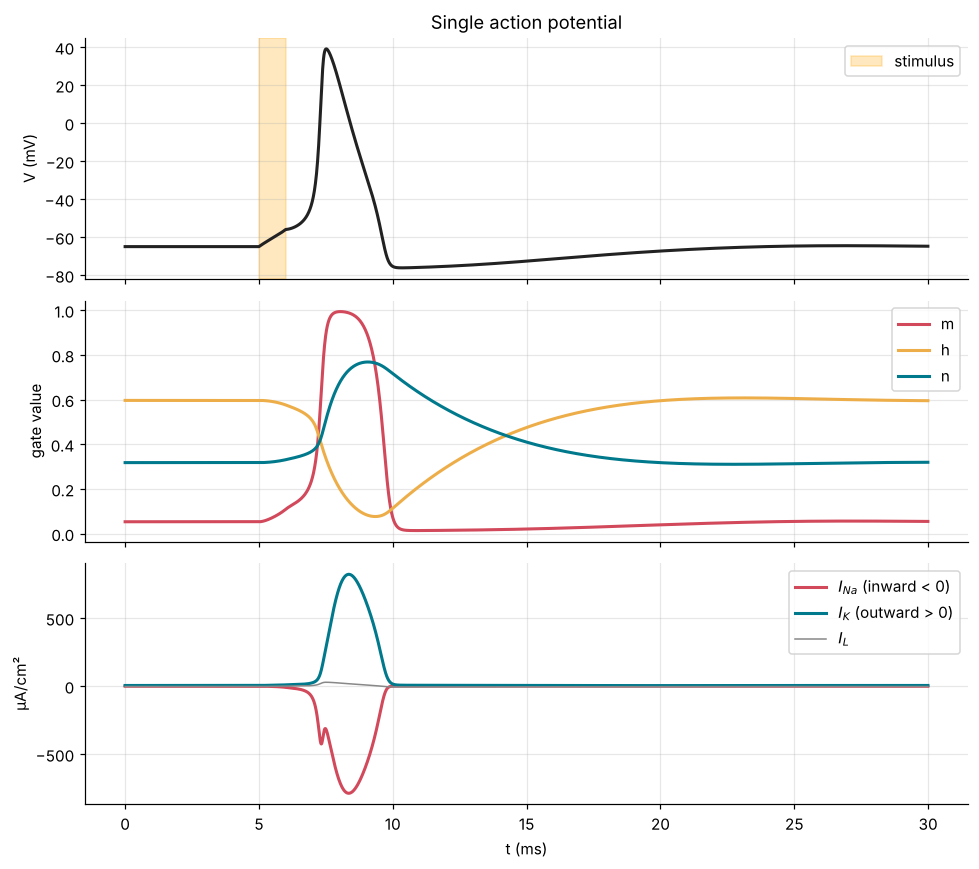

Peak V = 39.1 mV at t = 7.51 ms;  min V = -76.2 mV


In [5]:
t, y = simulate(pulse(10, 5, 6), T=30)
V, m, h, n = y
INa, IK, IL = currents(V, m, h, n)

fig, ax = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
ax[0].plot(t, V, color=COL["V"], lw=2); ax[0].set_ylabel("V (mV)")
ax[0].axvspan(5, 6, color="orange", alpha=0.25, label="stimulus"); ax[0].legend(loc="upper right")
for g, arr in zip("mhn", (m, h, n)):
    ax[1].plot(t, arr, color=COL[g], lw=2, label=g)
ax[1].set_ylabel("gate value"); ax[1].legend(loc="upper right")
ax[2].plot(t, INa, color=COL["INa"], lw=2, label=r"$I_{Na}$ (inward < 0)")
ax[2].plot(t, IK, color=COL["IK"], lw=2, label=r"$I_K$ (outward > 0)")
ax[2].plot(t, IL, color=COL["IL"], lw=1, label=r"$I_L$")
ax[2].set_ylabel("µA/cm²"); ax[2].set_xlabel("t (ms)"); ax[2].legend(loc="upper right")
ax[0].set_title("Single action potential")
plt.tight_layout(); plt.show()

print(f"Peak V = {V.max():.1f} mV at t = {t[V.argmax()]:.2f} ms;  min V = {V.min():.1f} mV")

## 6. Threshold

Vary the pulse amplitude (1 ms pulses). Below threshold, V makes a small bump and decays; above it, a full all-or-none spike appears.

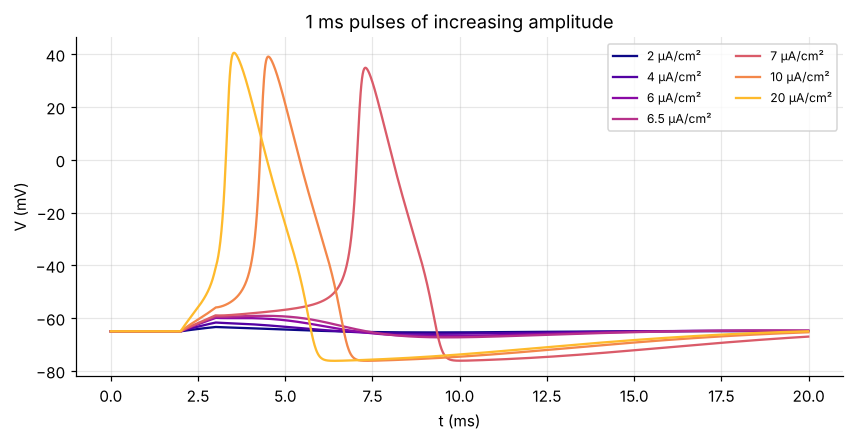

Threshold for a 1 ms pulse ≈ 6.92 µA/cm²


In [6]:
amps = [2, 4, 6, 6.5, 7, 10, 20]
plt.figure(figsize=(9, 4))
cm_ = plt.cm.plasma(np.linspace(0, 0.85, len(amps)))
for A, c in zip(amps, cm_):
    t, y = simulate(pulse(A, 2, 3), T=20)
    plt.plot(t, y[0], color=c, label=f"{A} µA/cm²")
plt.xlabel("t (ms)"); plt.ylabel("V (mV)"); plt.title("1 ms pulses of increasing amplitude")
plt.legend(fontsize=8, ncol=2); plt.show()

# Find the threshold by bisection
def spikes(A):
    t, y = simulate(pulse(A, 2, 3), T=20)
    return y[0].max() > 0
lo, hi = 1.0, 20.0
for _ in range(25):
    mid = 0.5 * (lo + hi)
    lo, hi = (lo, mid) if spikes(mid) else (mid, hi)
print(f"Threshold for a 1 ms pulse ≈ {hi:.2f} µA/cm²")

## 7. Refractory period

Give a first suprathreshold pulse, then a second, identical pulse after a delay Δt. For short delays the second pulse fails because h is still low (Na⁺ channels inactivated) and n is still high.

The second plot finds, for each delay, the minimum amplitude needed to fire again: it is infinite (absolute refractory period) at first, then elevated (relative refractory period), then back to normal.

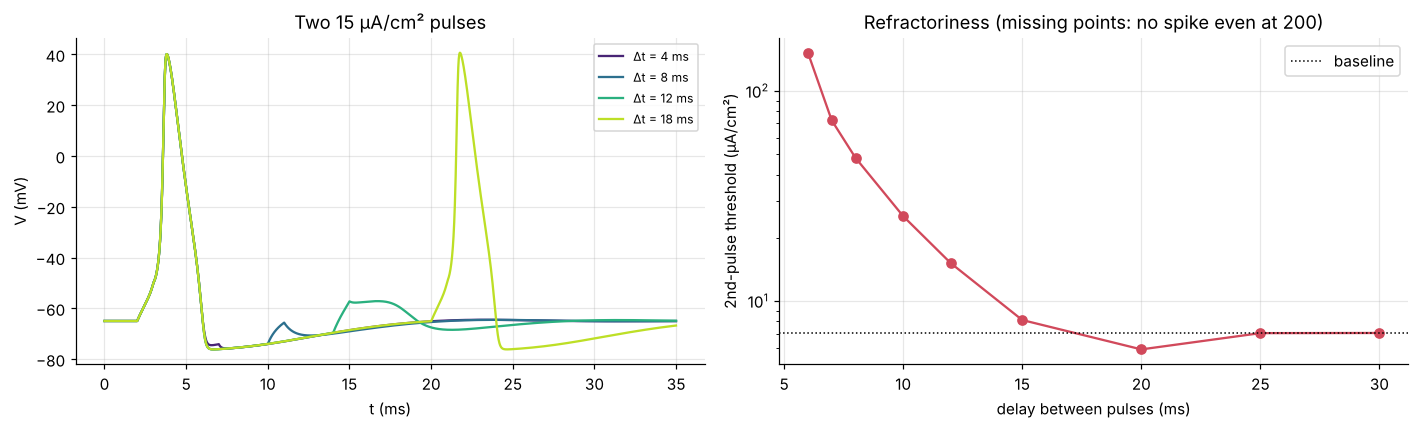

In [7]:
A1 = 15
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for d, c in zip([4, 8, 12, 18], plt.cm.viridis(np.linspace(0.1, 0.9, 4))):
    I = lambda t, d=d: A1 if (2 <= t < 3) or (2 + d <= t < 3 + d) else 0.0
    t, y = simulate(I, T=35)
    ax[0].plot(t, y[0], color=c, label=f"Δt = {d} ms")
ax[0].set_xlabel("t (ms)"); ax[0].set_ylabel("V (mV)"); ax[0].legend(fontsize=8)
ax[0].set_title(f"Two {A1} µA/cm² pulses")

def second_threshold(d, Amax=200):
    def fires(A):
        I = lambda t: A1 if 2 <= t < 3 else (A if 2 + d <= t < 3 + d else 0.0)
        t, y = simulate(I, T=2 + d + 15)
        return y[0][t >= 2 + d].max() > 0
    if not fires(Amax): return np.nan
    lo, hi = 0.0, Amax
    for _ in range(14):
        mid = 0.5 * (lo + hi)
        lo, hi = (lo, mid) if fires(mid) else (mid, hi)
    return hi

delays = np.array([3, 4, 5, 6, 7, 8, 10, 12, 15, 20, 25, 30])
thr = np.array([second_threshold(d) for d in delays])
ax[1].plot(delays, thr, "o-", color="#d1495b")
ax[1].axhline(thr[-1], color="k", ls=":", lw=1, label="baseline")
ax[1].set_yscale("log"); ax[1].set_xlabel("delay between pulses (ms)")
ax[1].set_ylabel("2nd-pulse threshold (µA/cm²)"); ax[1].legend()
ax[1].set_title("Refractoriness (missing points: no spike even at 200)")
plt.tight_layout(); plt.show()

## 8. Repetitive firing and the f–I curve

Now apply a **sustained** current. Below about 6–7 µA/cm² the neuron gives at most one spike and settles; above, it fires periodically.

The firing-rate vs current (f–I) curve jumps from 0 to a nonzero rate: there is a **minimum firing rate**, the signature of the Hopf bifurcation mentioned in the Wikipedia article.

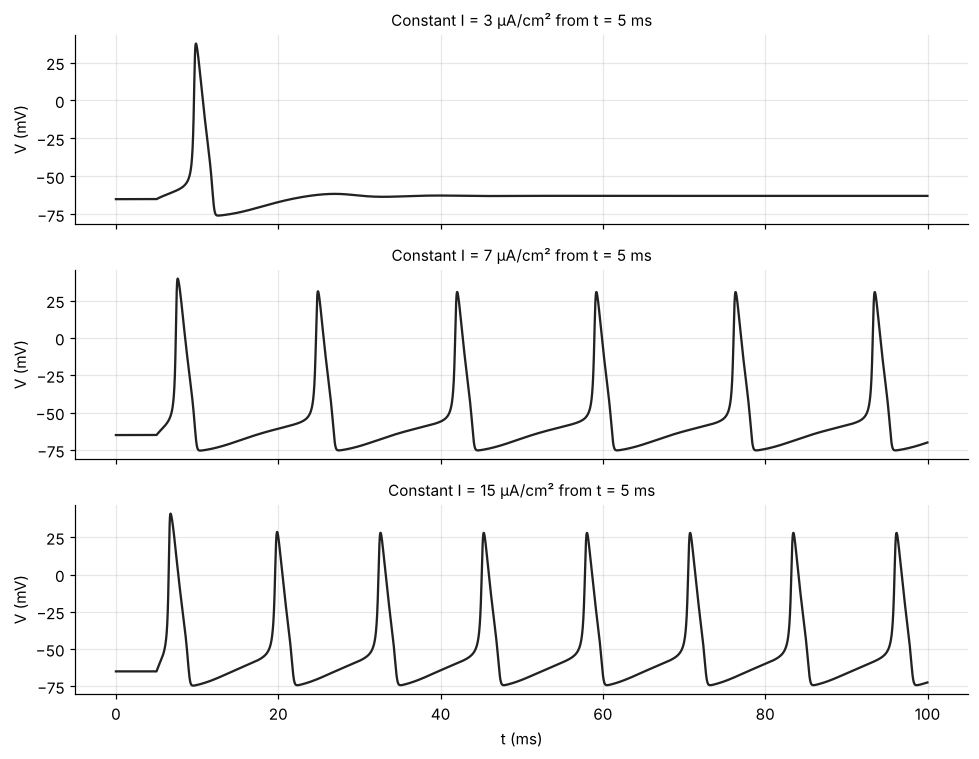

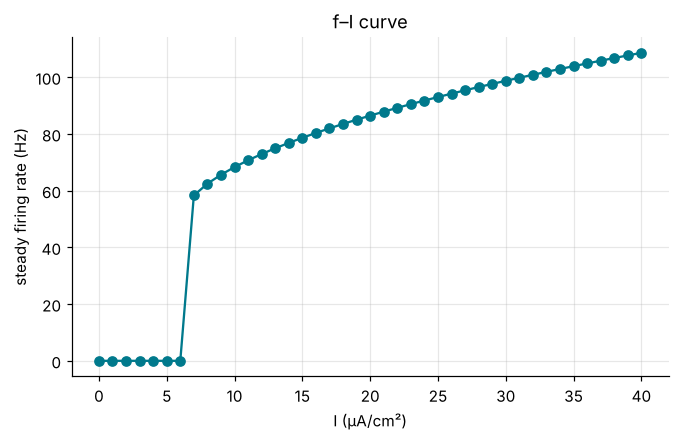

Repetitive firing starts between 6 and 7 µA/cm², at about 58 Hz (not 0 Hz).


In [8]:
step = lambda A: (lambda t: A if t >= 5 else 0.0)
fig, ax = plt.subplots(3, 1, figsize=(9, 7), sharex=True)
for a, A in zip(ax, [3, 7, 15]):
    t, y = simulate(step(A), T=100)
    a.plot(t, y[0], color=COL["V"]); a.set_ylabel("V (mV)")
    a.set_title(f"Constant I = {A} µA/cm² from t = 5 ms", fontsize=10)
ax[-1].set_xlabel("t (ms)")
plt.tight_layout(); plt.show()

def rate(A, T=300, t_skip=100):
    t, y = simulate(step(A), T=T, dt_out=0.02)
    V = y[0]
    up = np.where((V[:-1] < 0) & (V[1:] >= 0))[0]
    up = up[t[up] > t_skip]
    if len(up) < 2: return 0.0
    return 1000.0 / np.mean(np.diff(t[up]))   # Hz

Is = np.arange(0, 41, 1.0)
f = np.array([rate(A) for A in Is])
plt.figure(figsize=(7, 4))
plt.plot(Is, f, "o-", color="#00798c")
plt.xlabel("I (µA/cm²)"); plt.ylabel("steady firing rate (Hz)"); plt.title("f–I curve")
plt.show()
i_on = np.argmax(f > 0)
print(f"Repetitive firing starts between {Is[i_on-1]:.0f} and {Is[i_on]:.0f} µA/cm², "
      f"at about {f[i_on]:.0f} Hz (not 0 Hz).")

## 9. Phase-space view

The state lives in 4D (V, m, h, n). Projecting onto the **V–n plane** (as the Wikipedia article does):
- Rest is a **fixed point** (black dot).
- A single spike is a large **excursion** that returns to the fixed point.
- Repetitive firing settles onto a closed loop, a **limit cycle**.

Remember this is a 2D shadow of a 4D trajectory.

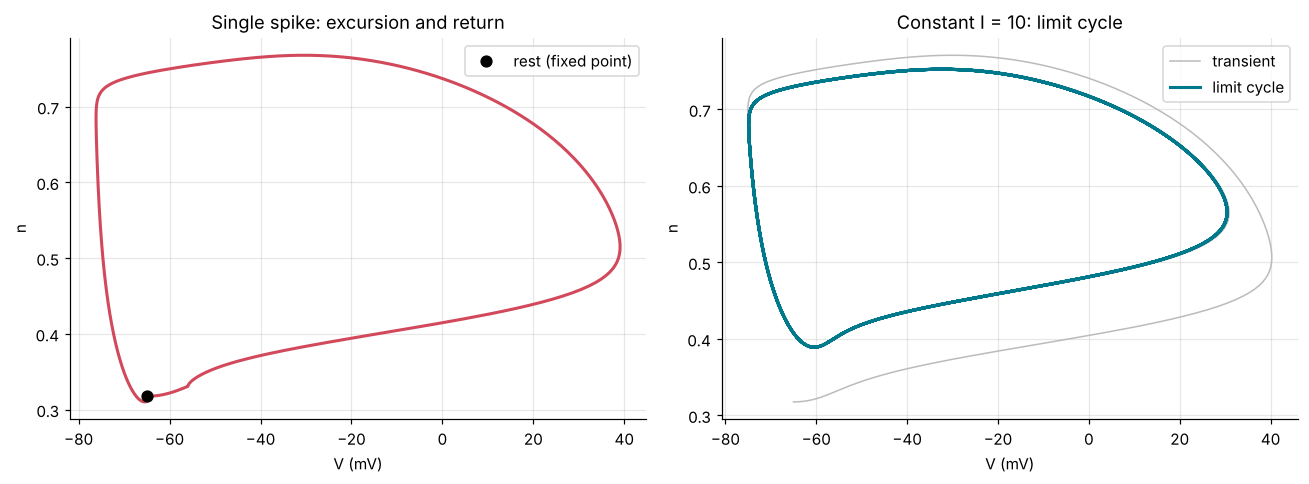

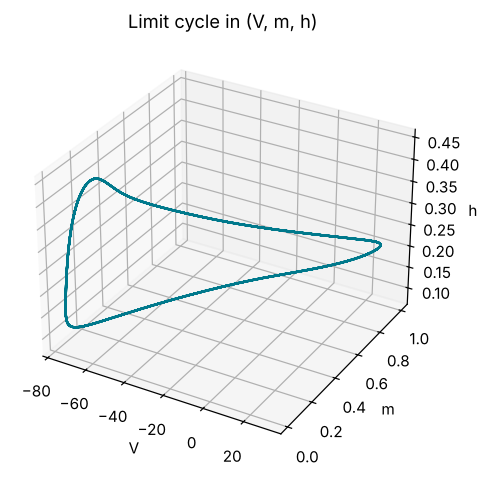

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
t, y = simulate(pulse(10, 2, 3), T=25)
ax[0].plot(y[0], y[3], color="#d1495b", lw=2)
ax[0].plot(V0, x_inf("n", V0), "ko", ms=7, label="rest (fixed point)")
ax[0].set_title("Single spike: excursion and return")

t, y = simulate(step(10), T=150)
k = t > 60
ax[1].plot(y[0][~k], y[3][~k], color="#bbbbbb", lw=1, label="transient")
ax[1].plot(y[0][k], y[3][k], color="#00798c", lw=2, label="limit cycle")
ax[1].set_title("Constant I = 10: limit cycle")
for a in ax:
    a.set_xlabel("V (mV)"); a.set_ylabel("n"); a.legend()
plt.tight_layout(); plt.show()

# 3D view: V, m, h
from mpl_toolkits.mplot3d import Axes3D  # noqa
fig = plt.figure(figsize=(6, 5)); a3 = fig.add_subplot(projection="3d")
a3.plot(y[0][k], y[1][k], y[2][k], color="#00798c")
a3.set_xlabel("V"); a3.set_ylabel("m"); a3.set_zlabel("h"); a3.set_title("Limit cycle in (V, m, h)")
plt.show()

## 10. Forward Euler vs Rush–Larsen (gates)

Your own fixed-step solver, using exactly the gate updates we discussed:
- **Forward Euler:** $x^{n+1} = x^n + \Delta t\,(x_\infty - x^n)/\tau$
- **Rush–Larsen:** $x^{n+1} = x_\infty + (x^n - x_\infty)e^{-\Delta t/\tau}$

(Voltage uses forward Euler in both, with the new gates.) Compare against the accurate `solve_ivp` reference at increasing Δt.

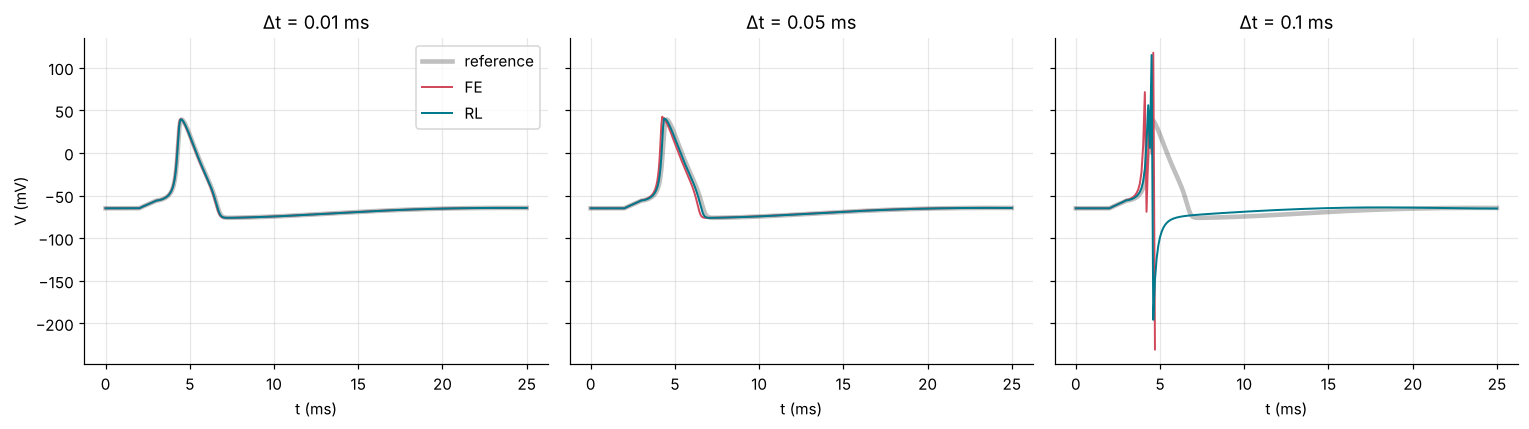

Peak-time error vs reference (ms):


  dt = 0.005  FE: 0.0240   RL: 0.0140


  dt = 0.01   FE: 0.0440   RL: 0.0240
  dt = 0.025  FE: 0.1140   RL: 0.0640
  dt = 0.05   FE: 0.2640   RL: 0.1140
  dt = 0.1    FE: inf   RL: 0.0140


In [10]:
def fixed_step(Iext, T, dt, gate_method="RL"):
    N = int(round(T / dt))
    t = np.arange(N + 1) * dt
    V, m, h, n = rest_state()
    out = np.empty(N + 1); out[0] = V
    for k in range(N):
        new = []
        for g, x in zip("mhn", (m, h, n)):
            xi, tt = x_inf(g, V), tau(g, V)
            if gate_method == "RL":
                new.append(xi + (x - xi) * np.exp(-dt / tt))
            else:
                new.append(x + dt * (xi - x) / tt)
        m, h, n = new
        INa, IK, IL = currents(V, m, h, n)
        V = V + dt * (Iext(t[k]) - INa - IK - IL) / Cm
        out[k + 1] = V
        if not np.isfinite(V) or abs(V) > 1e3:
            out[k + 1:] = np.nan; break
    return t, out

I = pulse(10, 2, 3); T = 25
tr, yr = simulate(I, T=T, dt_out=0.001)

fig, ax = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for a, dt in zip(ax, [0.01, 0.05, 0.1]):
    a.plot(tr, yr[0], color="k", lw=3, alpha=0.25, label="reference")
    for meth, c in [("FE", "#d1495b"), ("RL", "#00798c")]:
        t, V = fixed_step(I, T, dt, meth)
        a.plot(t, V, color=c, lw=1.3, label=meth)
    a.set_title(f"Δt = {dt} ms"); a.set_xlabel("t (ms)")
ax[0].set_ylabel("V (mV)"); ax[0].legend()
plt.tight_layout(); plt.show()

print("Peak-time error vs reference (ms):")
t_ref_peak = tr[np.nanargmax(yr[0])]
for dt in [0.005, 0.01, 0.025, 0.05, 0.1]:
    row = []
    for meth in ("FE", "RL"):
        t, V = fixed_step(I, T, dt, meth)
        row.append(abs(t[np.nanargmax(V)] - t_ref_peak) if np.isfinite(V).all() else np.inf)
    print(f"  dt = {dt:<6} FE: {row[0]:.4f}   RL: {row[1]:.4f}")

## Things to try
- Change `gK` or `gNa` and watch the spike shape and threshold change.
- Block Na⁺ (`gNa = 0`) or K⁺ (`gK = 0`) channels (like TTX / TEA).
- Use a negative current pulse (−10 µA/cm² for 5 ms) and see **anode-break excitation**: a spike after release from hyperpolarization (h recovers above rest, m snaps back).
- Plot $m_\infty^3 h_\infty$ vs V to see the steady "window" Na⁺ conductance.